#### Setup

In [ ]:
import os
import re
import numpy as np
import matplotlib as mat
import matplotlib.pyplot as plt
import scipy as scipy
from scipy import optimize
from matplotlib.ticker import AutoMinorLocator
from matplotlib import gridspec
import matplotlib.ticker as ticker
import pandas as pd
from scipy.signal import find_peaks, savgol_filter

%matplotlib inline


In [81]:
def peak_filter(input,minmax=[1.65, 1.75]):
    raw = np.array(input)
    lens = np.shape(raw)[0]
    for i in range(lens):
        current_peak = raw[i,:]
        for j in range(np.size(current_peak)):
            if current_peak[j] < minmax[0] or current_peak[j] > minmax[1]:
                raw[i,j] = np.nan
    return raw

In [82]:
def twolevel_LE(x, X1, X2, p1, p2, D):
    return (X2+X1+p2*x-p1*x)/2-np.sqrt((X2+X1+p2*x-p1*x)**2-4*(X2+p2*x)*(X1-p1*x)+4*D**2)/2
def dipole1(x,X2,p2):
    return (X2+x*p2)
def dipole2(x,X1,p1):
    return (X1-x*p1)

In [83]:
def twolevel_fitting(inputX, inputY, title = '2LevelFitting'):
    params, covariance = optimize.curve_fit(twolevel_LE, inputX, inputY,nan_policy='omit')
    perr = np.sqrt(np.diag(covariance))
    residual = inputY- (twolevel_LE(inputX,*params))
    ss_res = np.nansum(residual**2)
    ss_tot = np.nansum((inputY-np.nanmean(inputY))**2)
    r_squared = 1 - (ss_res / ss_tot)

    # plot
    fig, ax = plt.subplots()
    ax.scatter(inputX, inputY, label='Data', s=5)
    ax.plot(inputX, twolevel_LE(inputX,*params), label='2Level_LE', color='red')
    stats = (f'X1 = {params[0]:.4f} +/- {perr[0]:.4f}\n'
            f'X2 = {params[1]:.4f} +/- {perr[1]:.4f}\n'
            f'p1 = {params[2]:.4f} +/- {perr[2]:.4f}\n'
            f'p2 = {params[3]:.4f} +/- {perr[3]:.4f}\n'
            f'Delta = {params[4]:.4f} +/- {perr[4]:.4f}\n'
            f'R^2 = {r_squared:.4f}')
    bbox = dict(boxstyle='round', fc='#99FF99', ec='orange', alpha=0.5)
    ax.text(0.02, 0.97, stats, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=bbox)
    plt.legend()
    # plt.xlim(-10,10)
    plt.xlabel('TG-BG (V)')
    plt.ylabel('Photon Energy (eV)')
    plt.title(title)
    plt.show()
    return fig


In [84]:
def sum_select_region(input_matrix, energy, min_energy, max_energy,baseline=595):
#  input Intensity matrix and energy and (min,max) and baseline, return intensity sum between (min, max)
    matrix_size = input_matrix.shape[0]
    intensity_sum = np.zeros((matrix_size,1))
    energy_indices = np.where((energy > min_energy) & (energy < max_energy))
    basic_count = baseline
    for i in range(matrix_size):
        try:
            sum = 0
            y = input_matrix[i,:]
            sum = np.sum(y[energy_indices])- basic_count* energy_indices[0].size
            intensity_sum[i,0]= sum  
        except:
            print('e')
    return intensity_sum

In [85]:
def rc_peak_to_peak(energy, rc_spectrum, e_lo=1.836, e_hi=1.853):
    """Return peak-to-peak amplitude (max - min) inside [e_lo, e_hi]."""
    e = np.asarray(energy).ravel()
    rc = np.asarray(rc_spectrum).ravel()

    mask = (e >= e_lo) & (e <= e_hi)
    if not np.any(mask):
        raise ValueError("No points in the specified window.")

    rc_window = rc[mask]
    amp = np.max(rc_window) - np.min(rc_window)
    return amp, np.max(rc_window), np.min(rc_window)

In [104]:
def rc_peak_pos(energy, spec_intensity, e_lo, e_hi):
    """
    Find the dominant peak position and value in a spectrum within [e_lo, e_hi].

    Parameters
    ----------
    energy : array-like
        1D array of x-values (e.g., Photon energy in eV), monotonically increasing or decreasing.
    spec_intensity : array-like
        1D array of y-values (same length as energy).
    e_lo, e_hi : float
        Search window (inclusive) in the same units as `energy`.

    Returns
    -------
    peak_E : float
        Energy position of the strongest peak (refined by quadratic interpolation), or np.nan.
    peak_Y : float
        Peak height (at refined position), or np.nan.
    """
    # --- to arrays & finite mask
    x = np.asarray(energy, dtype=float)
    y = np.asarray(spec_intensity, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if not np.any(m):
        return np.nan, np.nan
    idx_full = np.where(m)[0]
    x, y = x[m], y[m]

    # --- restrict to [e_lo, e_hi] (handle ascending or descending axes)
    lo, hi = (e_lo, e_hi) if e_lo <= e_hi else (e_hi, e_lo)
    w = (x >= lo) & (x <= hi)
    if not np.any(w):
        return np.nan, np.nan
    xw, yw = x[w], y[w]
    idx_w2f = idx_full[w]
    # --- ensure we have enough points
    n = xw.size
    if n < 3:
        return np.nan, np.nan

    # --- light smoothing (odd window <= n, >= 5)
    wl = max(5, min(n if n % 2 == 1 else n - 1, 21))  # cap at 21 for stability
    yw_s = savgol_filter(yw, window_length=wl, polyorder=2, mode="interp")

    # --- helper: choose strongest extremum by value, then refine with quadratic fit
    def _best_peak(xa, ya, invert=False):
        ya_use = -ya if invert else ya
        # adaptive prominence: fraction of dynamic range
        dyn = float(np.nanmax(ya_use) - np.nanmin(ya_use))
        prom = max(1e-12, 0.02 * dyn)  # 2% of range
        idx, props = find_peaks(ya_use, prominence=prom)
        if idx.size == 0:
            # try looser if nothing found
            idx, props = find_peaks(ya_use, prominence=max(1e-12, 0.005 * dyn))
            if idx.size == 0:
                return None

        # pick by actual y (peak height or dip depth after invert handling)
        if invert:
            # deeper dip = larger (-ya); equivalently smaller original ya
            order = np.argsort(ya[idx])  # ascending -> deepest first
        else:
            order = np.argsort(-ya[idx]) # descending -> tallest first
        i = idx[order[0]]

        # quadratic (parabolic) refinement using neighbors if available
        if 0 < i < len(ya) - 1:
            x0, x1, x2 = xa[i-1], xa[i], xa[i+1]
            y0, y1, y2 = ya[i-1], ya[i], ya[i+1]
            denom = (y0 - 2*y1 + y2)
            if denom != 0:
                # shift in sample units toward the vertex
                dx = 0.5 * (y0 - y2) / denom
                # convert shift to x-units (approximate using local spacing)
                # local spacing estimated as (x2 - x0)/2
                x_peak = x1 + dx * (x2 - x0) / 2.0
                # vertex value
                y_peak = y1 - 0.25 * (y0 - y2) * dx
                return float(x_peak), float(y_peak)
        # fallback: sample point
        return float(xa[i]), float(ya[i])

    # 1) try maxima
    res = _best_peak(xw, yw_s, invert=False)
    if res is not None:
        # report value from unsmoothed curve at nearest index to refined x
        xpk, ypk_s = res
        j = int(np.clip(np.searchsorted(xw, xpk) - 1, 0, n - 1))
        # choose the nearer of j and j+1 if available
        if j + 1 < n and abs(xw[j+1] - xpk) < abs(xw[j] - xpk):
            j = j + 1
        return xpk, float(yw[j])

    # 2) if no maxima, try minima (dips)
    res = _best_peak(xw, yw_s, invert=True)
    if res is not None:
        xpk, ypk_s = res
        j = int(np.clip(np.searchsorted(xw, xpk) - 1, 0, n - 1))
        if j + 1 < n and abs(xw[j+1] - xpk) < abs(xw[j] - xpk):
            j = j + 1
        return xpk, float(yw[j])

    # nothing found
    return np.nan, np.nan
    

In [108]:
def rc_dip_pos(energy, spec_intensity, e_lo, e_hi):
    x = np.asarray(energy, dtype=float)
    y = np.asarray(spec_intensity, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    if not np.any(m): return np.nan, np.nan
    idx_full = np.where(m)[0]
    x, y = x[m], y[m]

    lo, hi = (e_lo, e_hi) if e_lo <= e_hi else (e_hi, e_lo)
    w = (x >= lo) & (x <= hi)
    if not np.any(w): return np.nan, np.nan
    xw, yw = x[w], y[w]
    idx_w2f = idx_full[w]
    n = xw.size
    if n < 3: return np.nan, np.nan

    wl = max(5, min(21, n if n % 2 else n - 1))
    ys = savgol_filter(yw, wl, 2, mode="interp")

    dyn = float(np.nanmax(ys) - np.nanmin(ys))
    prom = max(1e-12, 0.02 * dyn)
    dips, _ = find_peaks(-ys, prominence=prom)
    if dips.size == 0:
        dips, _ = find_peaks(-ys, prominence=max(1e-12, 0.005 * dyn))
        if dips.size == 0: return np.nan, np.nan

    i = dips[np.argmin(ys[dips])]

    # refine x_ref, then SNAP to nearest raw sample (no interpolation)
    if 0 < i < n - 1:
        y0, y1, y2 = ys[i-1], ys[i], ys[i+1]
        denom = (y0 - 2*y1 + y2)
        if denom != 0:
            dx = 0.5 * (y0 - y2) / denom
            x_ref = xw[i] + dx * (xw[i+1] - xw[i-1]) / 2.0
            j = int(np.argmin(np.abs(xw - x_ref)))   # <- key change
        else:
            j = i
    else:
        j = i

    j_full = int(idx_w2f[j])
    return float(x[j_full]), float(y[j_full])

In [87]:
# extract all constant-dopinf or constant-efield lines from Intensity grid and save plots + CSVs
def extract_all_lines(Intensity, energy, vbg_data, vtg_data, tg_bg_ratio,
                      mode='S', out_dir='.', title_prefix=None, y_label=None,
                      out_prefix=None, clim=None, levels=200, cmap='jet',clabel='PL intensity (a.u.)',
                      ylim=None, dpi=300, apply_medfilt=True, med_kernel=3,
                      wavelength=None, min_rows=2, save_csv_if_skipped=True):
                      
    """
    Extract all constant-S or constant-U lines from Intensity grid and save plots + CSVs.

    Intensity: (N, nE) array, each row is a spectrum
    energy:   (nE,), in eV
    vbg_data: (N,)
    vtg_data: (N,)
    mode: 'S' (0.8*Vtg+Vbg) or 'U' (0.8*Vtg-Vbg)
    wavelength: (nE,), optional for CSV header
    """
    os.makedirs(out_dir, exist_ok=True)

    nE = Intensity.shape[1]

    # Derived axes
    S_all = tg_bg_ratio * vtg_data + vbg_data
    U_all = tg_bg_ratio * vtg_data - vbg_data

    # Grid steps
    dvtg = np.unique(np.round(np.diff(np.unique(vtg_data)), 10))[0]
    dvbg = np.unique(np.round(np.diff(np.unique(vbg_data)), 10))[0]
    dS = tg_bg_ratio * dvtg
    dU = dS

    if mode.upper() == 'S':
        bin_axis = S_all
        sort_axis = U_all
        title_prefix = title_prefix or 'Doping='
        y_label = y_label or rf'{tg_bg_ratio}·Vtg − Vbg (V)'
        out_prefix = out_prefix or 'Doping'
        step = dS
    else:
        bin_axis = U_all
        sort_axis = S_all
        title_prefix = title_prefix or 'Efield='
        y_label = y_label or rf'{tg_bg_ratio}·Vtg + Vbg (V)'
        out_prefix = out_prefix or 'Efield'
        step = dU

    # Bin each row
    bmin = bin_axis.min()
    b_idx = np.rint((bin_axis - bmin) / step).astype(int)

    # Group rows by bin
    order = np.argsort(b_idx)
    b_sorted = b_idx[order]
    cuts = np.flatnonzero(np.diff(b_sorted)) + 1
    groups = np.split(order, cuts)

    for g in groups:
        spec_g = Intensity[g, :]         # (m, nE)
        y_vals = sort_axis[g]
        srt = np.argsort(y_vals)
        y_vals = y_vals[srt]
        Z = spec_g[srt, :]

        if apply_medfilt and Z.shape[0] >= 2:
            Z = medfilt2d(Z, kernel_size=med_kernel)

        bin_id = b_idx[g[0]]
        bin_value = bmin + bin_id * step
        name_value = np.round(bin_value, 2)

        # --- handle single-row bins ---
        if Z.shape[0] < min_rows:
            if save_csv_if_skipped:
                csv_out = np.zeros((Z.shape[0] + 1, nE + 4))
                if wavelength is not None:
                    csv_out[0, 4:] = wavelength
                csv_out[1:, 0] = vbg_data[g][srt]
                csv_out[1:, 1] = vtg_data[g][srt]
                csv_out[1:, 4:] = Z
                np.savetxt(os.path.join(out_dir, f'{out_prefix}={name_value}.csv'),
                           csv_out, delimiter=',', fmt='%.6g')
            continue

        # Color limits
        if clim is None:
            vmin = np.nanpercentile(Z, 2)
            vmax = np.nanpercentile(Z, 100)
            if not np.isfinite(vmin) or vmin == vmax:
                vmin, vmax = np.nanmin(Z), np.nanmax(Z)
        else:
            vmin, vmax = clim

        # Plot
        X, Y = np.meshgrid(energy, y_vals, indexing='xy')
        plt.figure(figsize=(6.2, 4.6))
        cs = plt.contourf(X, Y, Z,
                          levels=np.linspace(vmin, vmax, levels),
                          cmap=cmap)
        cbar = plt.colorbar(cs)
        cbar.set_label(clabel)

        plt.xlabel('Photon energy (eV)')
        plt.ylabel(y_label)
        if ylim is not None:
            plt.ylim(*ylim)

        title = f'{title_prefix}{name_value}'
        plt.title(title, color='red')
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f'{out_prefix}={name_value}.png'), dpi=dpi)
        plt.close()

        # CSV

        # csv_out = np.zeros((Z.shape[0] + 1, nE + 4))
        # if wavelength is not None:
        #     csv_out[0, 4:] = wavelength
        # csv_out[1:, 0] = vbg_data[g][srt]
        # csv_out[1:, 1] = vtg_data[g][srt]
        # csv_out[1:, 4:] = Z

        if mode.upper() == 'S':
            csv_out = np.zeros((Z.shape[0] + 1, nE + 1))
            if wavelength is not None:
                csv_out[0, 1:] = wavelength
            csv_out[1:, 0] = tg_bg_ratio * vtg_data[g][srt] - vbg_data[g][srt]
            csv_out[1:, 1:] = Z
        else:
            csv_out = np.zeros((Z.shape[0] + 1, nE + 1))
            if wavelength is not None:
                csv_out[0, 1:] = wavelength
            csv_out[1:, 0] = tg_bg_ratio * vtg_data[g][srt] + vbg_data[g][srt]
            csv_out[1:, 1:] = Z

        np.savetxt(os.path.join(out_dir, f'{out_prefix}={name_value}.csv'),
                   csv_out, delimiter=',', fmt='%.6g')

#### Single Plot Peak finder for matlab csv.

In [88]:
folder_path = './megasweep'
file_list = os.listdir(folder_path)
filtered_files = [file for file in file_list if re.search(r'TG\+BG', file) and file.endswith('.dat')]
for filename in filtered_files:
    print(filename)

FileNotFoundError: [WinError 3] The system cannot find the path specified: './megasweep'

In [ ]:
origin_name = filtered_files[11]
print(origin_name)
name = origin_name[:-4]

df = pd.read_csv(folder_path +origin_name)

$YZ129-2ndCD-5cmlens-5050BS$~$PL$~$P2new$~$730nm700uw$~$2s$~-$TG+BG=0$-001.dat


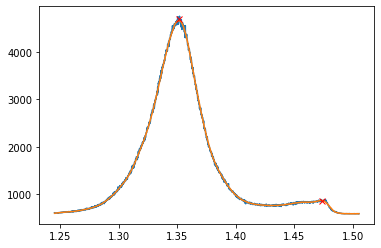

In [ ]:
raw_data =np.array(df)
energy = raw_data[2:,0]
Intensity = raw_data[2:,1:]
gate = raw_data[1,1:]
y = Intensity[:,30]
plt.plot(energy, y)
filtered_y = scipy.signal.savgol_filter(y, 70,2)
peaks, _ = scipy.signal.find_peaks(filtered_y,prominence=20,width=60,distance=40)
plt.plot(energy, filtered_y)
plt.plot(energy[peaks], y[peaks], "x",color='red')

In [ ]:
gate_len = np.shape(gate)[0]
results = np.zeros((gate_len,5))
for i in range(gate_len):
    try:
        y = Intensity[:,i]
        # plt.plot(energy, y)
        filtered_y = scipy.signal.savgol_filter(y, 70,2)
        peaks, _ = scipy.signal.find_peaks(filtered_y,prominence=20,width=60,distance=20)
        # plt.plot(energy, filtered_y)
        # plt.plot(energy[peaks], y[peaks], "x")
        # plt.savefig("{}.png".format(i), format="png",dpi=1000)
        # plt.clf()
        sorted_peaks = np.sort(peaks)[::-1]   
        for j in range(sorted_peaks.shape[0]):
            results[i,j]= energy[sorted_peaks[j]]            
    except RuntimeError as e:
        print('error')


NameError: name 'name' is not defined

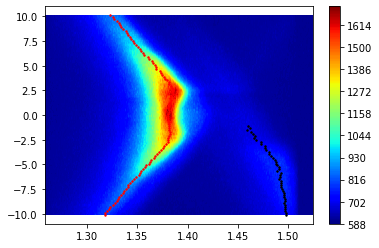

In [ ]:
filtered_peak = peak_filter(results)
# plt.scatter(filtered_peak[:,0],gate)
# plt.scatter(filtered_peak[:,1],gate)
# plt.scatter(filtered_peak[:,2],gate)
# plt.xlim(1.30,1.5)
# plt.ylim(-10,10)
# plt.title('peak position')
# # plt.figure(figsize=(3,6))
# plt.savefig(name+'.png', dpi=300, bbox_inches='tight')
# plt.close()

xv,yv = np.meshgrid(gate,energy,indexing='xy')
# plt.contourf(yv,xv ,Intensity,cmap='jet',levels=np.linspace(550, 1600, 200))
plt.contourf(yv,xv ,Intensity,cmap='jet',levels=200)
plt.colorbar()
plt.scatter(filtered_peak[:,0], gate, c='red',marker='o', label='Scatter Points',s=2)
plt.scatter(filtered_peak[:,1], gate, c='black',marker='o', label='Scatter Points',s=2)
plt.scatter(filtered_peak[:,2], gate, c='yellow',marker='o', label='Scatter Points',s=2)
plt.ylim(-11,11)
plt.title(name)
plt.savefig(name+'contour.png', dpi=600, bbox_inches='tight')
combined_peakinfo = np.zeros((gate_len,6))
combined_peakinfo[:,0] = gate
combined_peakinfo[:,1:] = filtered_peak
df_data = pd.DataFrame(combined_peakinfo)
df_data.to_csv(name+'peakinfo.csv',index=False)


#### Single Plot Peak finder for python csv.


# Megasweep processing

### read REF background


In [ ]:
#read REF background
back_folder_path = './'
back_file_list = [f for f in os.listdir(back_folder_path) if f.endswith('.csv') and 'background' in f.lower()]
for back_filename in back_file_list:
    print(back_filename)

$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_001.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_002.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_003.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_004.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_005.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_006.csv


In [ ]:
background = None

for back_filename in back_file_list:
    print(back_filename)
    df_background = pd.read_csv(back_filename, header=None)
    background_raw = np.array(df_background)

    # Take the spectrum part (row 0, columns from 4 onwards)
    spec = background_raw[1, 4:].astype(float)

    if background is None:
        background = spec.copy()
    else:
        background += spec   # elementwise add
energy = 1240/background_raw[0,4:].astype(float)
# Average over number of files
background = background / len(back_file_list)


$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_001.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_002.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_003.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_004.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_005.csv
$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$~$REF_forBackgroundend$_$TG-BG=0$_006.csv


energy = 1.683180794493497 to 1.8991223357896447


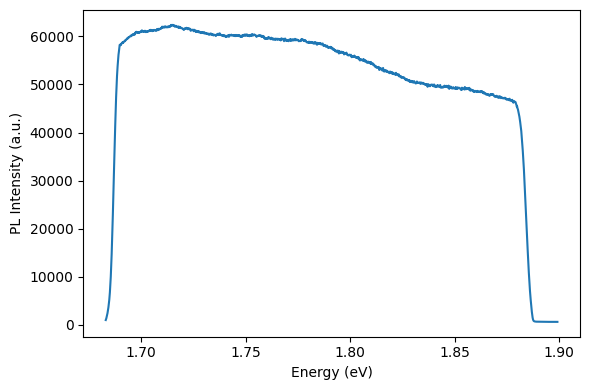

In [ ]:
# --- plot background ---
spec_energy = energy            # x-axis
print(f'energy = {np.min(energy)} to {np.max(energy)}')
plt.figure(figsize=(6,4))
plt.plot(spec_energy, background, lw=1.5)
plt.xlabel("Energy (eV)")
plt.ylabel("PL Intensity (a.u.)")
plt.tight_layout()
plt.show()

### read Megasweep data


In [ ]:
folder_path = './WSe2 mega'
file_list = os.listdir(folder_path)
for filename in file_list:
    print(filename)

$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$.csv


In [ ]:
# read REE data and geneerate RC spectra
df = pd.read_csv(f'{folder_path}/$Y320$~$REFMegaseep$~$4.5Kpa$~$695nmC$~$0.18sx10$.csv')
# name for figures
titlename = 'REF 695nm'

raw_data = np.array(df)
energy =  1240 / np.array(df.columns[2:].astype(float))
wavelength = np.array(df.columns[2:].astype(float))
vbg_data = raw_data[:,1]
vtg_data = raw_data[:,0]
matrix_size = vbg_data.size

peak_energy = np.zeros((matrix_size,5))
matrix_length = int(np.sqrt(matrix_size))

# --- grid dimensions ---
uniq_vbg = np.unique(vbg_data)
uniq_vtg = np.unique(vtg_data)
vbg_length = uniq_vbg.size
vtg_length = uniq_vtg.size

Raw_Intensity = raw_data[:,2:]
## if RC calculation needed, do here
RC_spectra = (Raw_Intensity - background) / background

## if PL megasweep, do here
# Intensity = Raw_Intensity


## Mega sweep contour

### REF peak-to-peak Amp contour

R2s peak-to-peak amplitude: 0.6848655153570792
energy = 1.683180794493497 to 1.8991223357896447


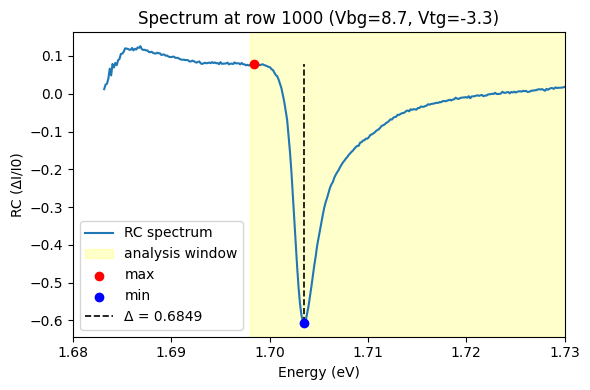

In [159]:
# --- pick one row ---
row_index = 1000   # change to whichever sweep point you want

spec_energy = energy
spec_intensity = RC_spectra[row_index, :]
e_lo, e_hi = 1.698, 1.73
# Compute peak-to-peak
amp, rc_max, rc_min = rc_peak_to_peak(energy, spec_intensity, e_lo, e_hi)

print("R2s peak-to-peak amplitude:", amp)
print(f'energy = {np.min(energy)} to {np.max(energy)}')

plt.figure(figsize=(6,4))
plt.plot(spec_energy, spec_intensity, lw=1.5, label="RC spectrum")

# Highlight analysis window
plt.axvspan(e_lo, e_hi, color="yellow", alpha=0.2, label="analysis window")

# Find indices for max and min
mask = (spec_energy >= e_lo) & (spec_energy <= e_hi)
idx_max = np.argmax(spec_intensity[mask])
idx_min = np.argmin(spec_intensity[mask])
energy_masked = spec_energy[mask]

# Coordinates of max and min
e_max, e_min = energy_masked[idx_max], energy_masked[idx_min]
plt.scatter([e_max], [rc_max], color="red", zorder=5, label="max")
plt.scatter([e_min], [rc_min], color="blue", zorder=5, label="min")

# Vertical line showing amplitude
plt.plot([e_min, e_min], [rc_min, rc_max], "k--", lw=1.2, label=f"Δ = {amp:.4f}")

plt.xlabel("Energy (eV)")
plt.xlim(1.68, 1.73)
# plt.ylim(-0.05, 0.05)
plt.ylabel("RC (ΔI/I0)")
plt.title(f"Spectrum at row {row_index} (Vbg={vbg_data[row_index]}, Vtg={vtg_data[row_index]})")
plt.legend()
plt.tight_layout()
plt.show()


In [160]:
e_lo, e_hi = 1.698, 1.73
# --- compute p2p for each row ---
RC_p2p = np.array([rc_peak_to_peak(energy, RC_spectra[i], e_lo, e_hi)[0]
                for i in range(RC_spectra.shape[0])])         # (n_rows,)

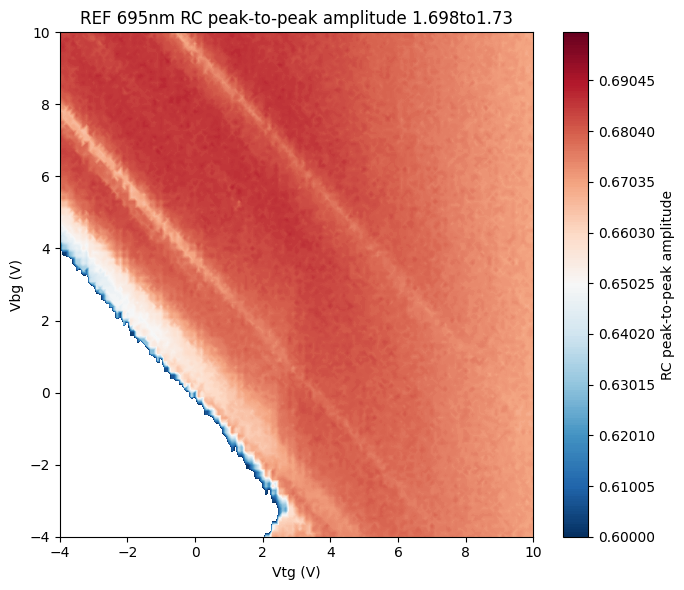

In [161]:
plt.figure(figsize=(7,6))

# Filled contour using triangulation (like Origin's "Contour - Triangulation")
# cont = plt.tricontourf(vtg_data, vbg_data, RC_p2p,
#                        levels=220, cmap="RdBu_r")
cont = plt.tricontourf(vtg_data, vbg_data, RC_p2p,
                       levels=np.linspace(0.6,0.7,200), cmap="RdBu_r")
plt.colorbar(cont, label="RC peak-to-peak amplitude")
plt.xlabel("Vtg (V)")
plt.ylabel("Vbg (V)")
plt.title(f"{titlename} RC peak-to-peak amplitude {e_lo}to{e_hi}")
plt.tight_layout()
plt.show()


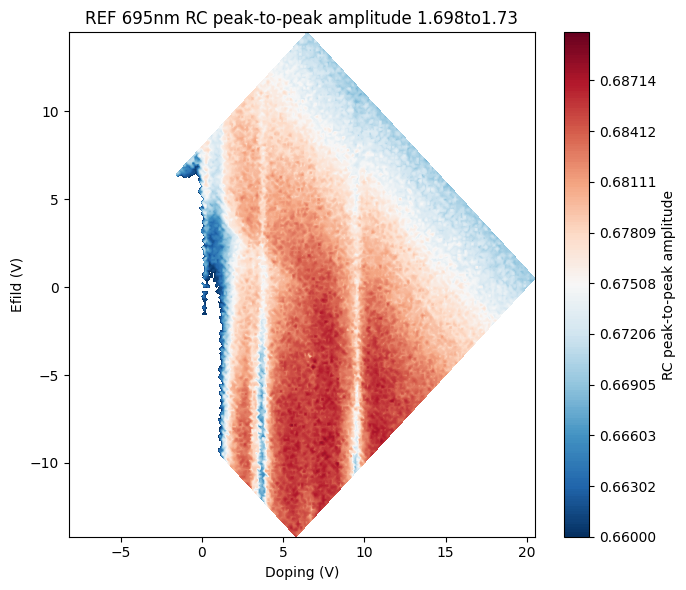

In [162]:
doping = 1.05*vtg_data + vbg_data
efield = 1.05*vtg_data - vbg_data
plt.figure(figsize=(7,6))

# Filled contour using triangulation (like Origin's "Contour - Triangulation")
# cont = plt.tricontourf(doping, efield, RC_p2p,
#                        levels=220, cmap="RdBu_r")
cont = plt.tricontourf(doping, efield, RC_p2p,
                       levels=np.linspace(0.66,0.69,200), cmap="RdBu_r")
plt.colorbar(cont, label="RC peak-to-peak amplitude")
plt.xlabel("Doping (V)")
plt.ylabel("Efild (V)")
plt.title(f"{titlename} RC peak-to-peak amplitude {e_lo}to{e_hi}")
plt.tight_layout()
plt.show()


In [163]:
# save to CSV

RC_p2p_grid = np.column_stack([vbg_data.ravel(), vtg_data.ravel(), RC_p2p.ravel()])

np.savetxt(f'RC-P2P-map_{e_lo}to{e_hi}eV_{titlename}.csv',
           RC_p2p_grid,
           delimiter=',',
           fmt='%.6f',
           header=f'vbg,vtg,RC-peak-to-peak{e_lo}to{e_hi}eV',
           comments='')

In [ ]:
# --- sort rows by (Vbg primary, Vtg secondary) ---
idx_flat = np.lexsort((vtg_data, vbg_data))
# --- reshape to 2D grids ---
VBG = vbg_data[idx_flat].reshape(vbg_length, vtg_length)
VTG = vtg_data[idx_flat].reshape(vbg_length, vtg_length)
P2P_grid = RC_p2p[idx_flat].reshape(vbg_length, vtg_length)

### RC peak to peak Position

"1.710524552263172"


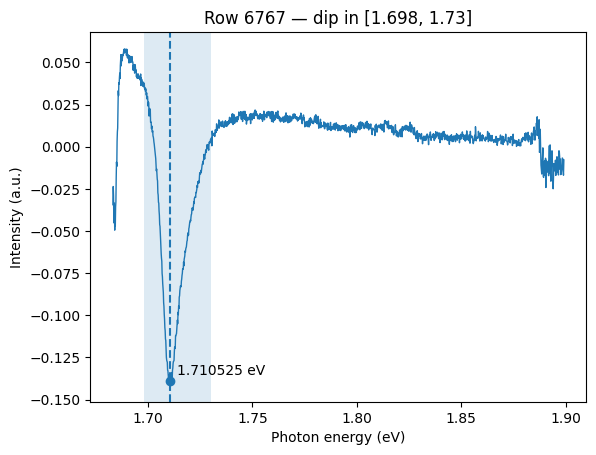

In [158]:
# --- pick one row ---
row_index = 6767        # change to whichever sweep point you want

spec_energy    = energy
spec_intensity = RC_spectra[row_index, :]
e_lo, e_hi     = 1.698, 1.73

# --- find peak position/value within [e_lo, e_hi]
e_pk, y_pk = rc_dip_pos(spec_energy, spec_intensity, e_lo, e_hi)
print(f'"{e_pk}"')

# plot
fig, ax = plt.subplots()
ax.plot(spec_energy, spec_intensity, linewidth=1)
ax.axvspan(min(e_lo, e_hi), max(e_lo, e_hi), alpha=0.15)

if np.isfinite(e_pk) and np.isfinite(y_pk):
    ax.axvline(e_pk, linestyle="--")
    ax.scatter([e_pk], [y_pk])
    ax.annotate(f"{e_pk:.6f} eV", xy=(e_pk, y_pk), xytext=(5, 5), textcoords="offset points")
    
ax.set_xlabel("Photon energy (eV)")
ax.set_ylabel("Intensity (a.u.)")
ax.set_title(f"Row {row_index} — dip in [{e_lo}, {e_hi}]")

# plt.xlim(1.8,1.85)
# plt.ylim(-0.05,0.05)
plt.show()


In [164]:
e_lo, e_hi = 1.698, 1.73
# --- compute p2p for each row ---
RC_dip_pos = np.array([rc_dip_pos(energy, RC_spectra[i], e_lo, e_hi)[0]
                for i in range(RC_spectra.shape[0])])         # (n_rows,)

In [165]:
# rows that contain NaN or ±inf
nan_idx = np.where(np.isnan(RC_dip_pos))[0]   # indices of NaNs
print(nan_idx)

[]


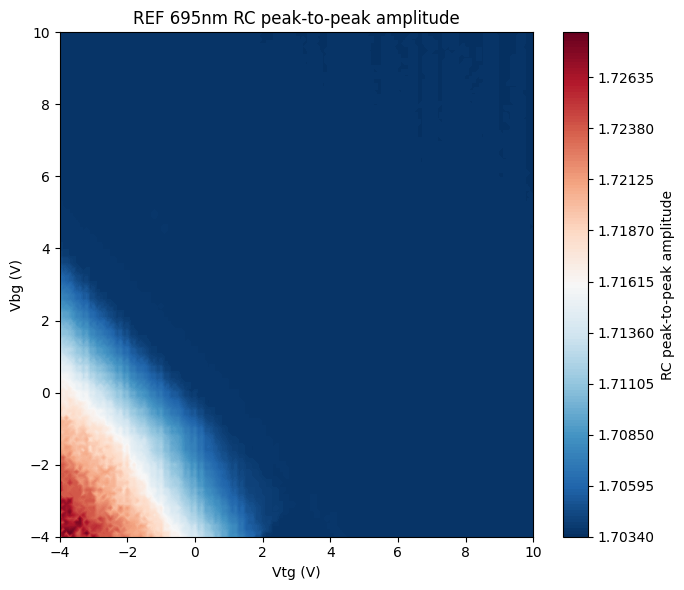

In [166]:
plt.figure(figsize=(7,6))

# Filled contour using triangulation (like Origin's "Contour - Triangulation")
cont = plt.tricontourf(vtg_data, vbg_data, RC_dip_pos,
                       levels=220, cmap="RdBu_r")

plt.colorbar(cont, label="RC peak-to-peak amplitude")
plt.xlabel("Vtg (V)")
plt.ylabel("Vbg (V)")
plt.title(f"{titlename} RC peak-to-peak amplitude")
plt.tight_layout()
plt.show()


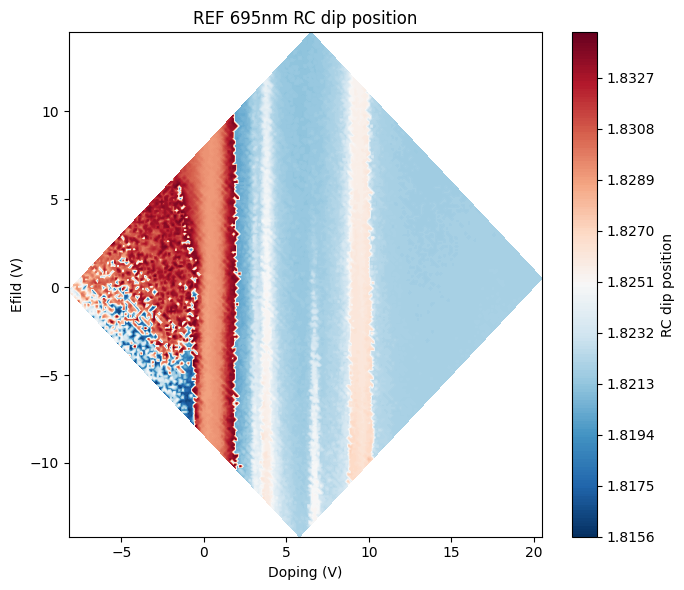

In [126]:
doping = 1.05*vtg_data + vbg_data
efield = 1.05*vtg_data - vbg_data
plt.figure(figsize=(7,6))

# Filled contour using triangulation (like Origin's "Contour - Triangulation")
cont = plt.tricontourf(doping, efield, RC_dip_pos,
                       levels=220, cmap="RdBu_r")

plt.colorbar(cont, label="RC dip position")
plt.xlabel("Doping (V)")
plt.ylabel("Efild (V)")
plt.title(f"{titlename} RC dip position")
plt.tight_layout()
plt.show()

In [ ]:
# save to CSV

RC_dip_pos_grid = np.column_stack([vbg_data.ravel(), vtg_data.ravel(), RC_dip_pos.ravel()])

np.savetxt(f'RC-dipPos-map_{e_lo}to{e_hi}eV_{titlename}.csv',
           RC_dip_pos_grid,
           delimiter=',',
           fmt='%.6f',
           header=f'vbg,vtg,RC-dip-pos-{e_lo}to{e_hi}eV',
           comments='')

### PL Intensity sum contour

energy = 1.6638126125141843 to 2.021522150907236


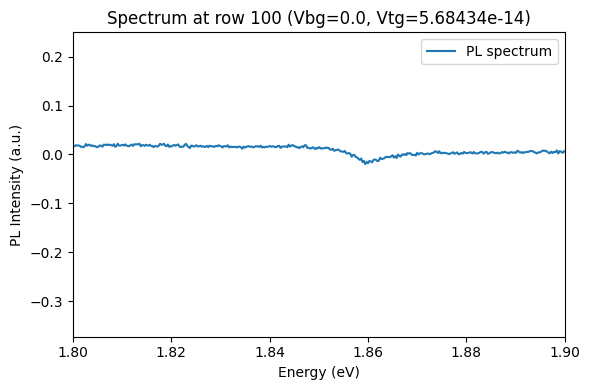

In [ ]:
# --- pick one row ---
row_index = 100   # change to whichever sweep point you want

spec_energy = energy
spec_intensity = Intensity[row_index, :]
print(f'energy = {np.min(energy)} to {np.max(energy)}')

plt.figure(figsize=(6,4))
plt.plot(spec_energy, spec_intensity, lw=1.5, label="PL spectrum")

plt.xlabel("Energy (eV)")
plt.xlim(1.8, 1.9)
plt.ylabel("PL Intensity (a.u.)")
plt.title(f"Spectrum at row {row_index} (Vbg={vbg_data[row_index]}, Vtg={vtg_data[row_index]})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
intensity_sum = sum_select_region(Intensity,energy=energy,
                                  min_energy=1.8,max_energy=1.9,
                                  baseline=0)

intensity_sum0 = intensity_sum[:,0]

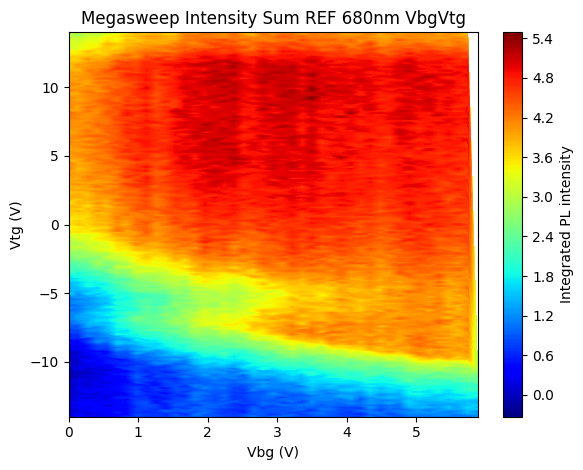

In [ ]:
#plot with x-axis Vbg / yaxis Vtg
plt.figure(figsize=(6, 4.8))
cs = plt.tricontourf(vbg_data, vtg_data, intensity_sum0, levels=220, cmap='jet') 
plt.colorbar(cs, label='Integrated PL intensity')
plt.xlabel('Vbg (V)')
plt.ylabel('Vtg (V)')
title_vbgvtg = f'Megasweep Intensity Sum {titlename} VbgVtg'
plt.title(title_vbgvtg)
plt.tight_layout()
plt.savefig(f'{title_vbgvtg}.png',dpi=600, bbox_inches='tight', transparent=True)
plt.show()

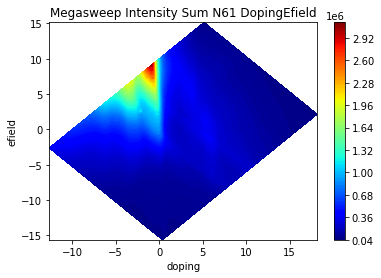

In [ ]:
from matplotlib.colors import LogNorm

doping = 1.27*vtg_data + vbg_data
efield = 1.27*vtg_data - vbg_data

plt.tricontourf(doping,efield,intensity_sum0,cmap='jet',levels=220)

plt.colorbar()
plt.xlabel('doping')
plt.ylabel('efield')
# plt.xlim(-30,10)
# plt.ylim(-6.5,6.5)
title_DE = f'Megasweep Intensity Sum {titlename} DopingEfield'

plt.title(title_DE)
plt.savefig(f'{title_DE}.png')
plt.show()

In [ ]:
# Stack and save: each row will be [doping, efield, intensity]
intensity_map_grid = np.column_stack([doping.ravel(), efield.ravel(), intensity_sum0.ravel()])

np.savetxt(f'Intensity-map_{titlename}_grid.csv',
           intensity_map_grid,
           delimiter=',',
           fmt='%.6f',
           header='doping,efield,intensity',
           comments='')


### PL Maximum intensity energy contour (smoothed)

Row 0: peak energy = 1.3535 eV


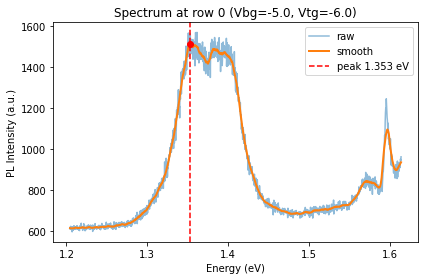

In [ ]:
from scipy.signal import savgol_filter

# --- pick one measurement point ---
row_index = 0   # change this to try different Vbg/Vtg sweep points
y_raw = Intensity[row_index, :]
E = energy

# smooth with Savitzky–Golay
win = min(25, y_raw.size if y_raw.size % 2 == 1 else y_raw.size-1)  # odd window <= spectrum length
if win < 5:  # very short spectra fallback
    win = max(3, y_raw.size if y_raw.size % 2 == 1 else y_raw.size-1)
y_smooth = savgol_filter(y_raw, window_length=win, polyorder=1)

# find peak energy
imax = np.argmax(y_smooth)
peak_E = E[imax]
peak_I = y_smooth[imax]

print(f"Row {row_index}: peak energy = {peak_E:.4f} eV")

# --- plot ---
plt.figure(figsize=(6,4))
plt.plot(E, y_raw, label="raw", alpha=0.5)
plt.plot(E, y_smooth, label="smooth", lw=2)
plt.axvline(peak_E, color='r', ls='--', label=f"peak {peak_E:.3f} eV")
plt.scatter([peak_E], [peak_I], color='r', zorder=5)
plt.xlabel("Energy (eV)")
plt.ylabel("PL Intensity (a.u.)")
plt.title(f"Spectrum at row {row_index} (Vbg={vbg_data[row_index]}, Vtg={vtg_data[row_index]})")
plt.legend()
plt.tight_layout()
plt.show()

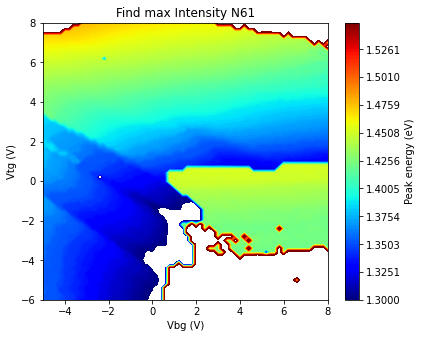

In [ ]:
# --- Peak energy per spectrum (vectorized & robust) ---
npts = Intensity.shape[1]

# choose an odd window ≤ npts; cap at 25
win = min(25, npts if npts % 2 == 1 else npts - 1)
if win < 5:  # tiny spectra fallback
    win = max(3, npts if npts % 2 == 1 else npts - 1)
poly = 1 if win > 2 else 0

# smooth along wavelength/energy axis
Yf = savgol_filter(Intensity, window_length=win, polyorder=poly, axis=1, mode='interp')

# handle NaNs safely (treat as -inf so they won't win argmax)
Yf_safe = np.where(np.isfinite(Yf), Yf, -np.inf)
max_idx = np.nanargmax(Yf_safe, axis=1)
max_energys = energy[max_idx]          # shape: (matrix_size,)


# --- Plot ---
plt.figure(figsize=(6, 4.8))
cs = plt.tricontourf(vbg_data, vtg_data, max_energys, levels=np.linspace(1.3, 1.55, 200), cmap='jet')

plt.colorbar(cs, label='Peak energy (eV)')
plt.xlabel('Vbg (V)')
plt.ylabel('Vtg (V)')
title_vbgvtg = f'Find max Intensity {titlename}'
plt.title(title_vbgvtg)
plt.tight_layout()
plt.savefig(f'{title_vbgvtg}.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()


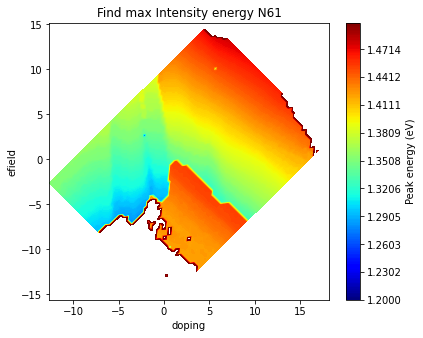

In [ ]:
# Plot
plt.figure(figsize=(6, 4.8))
cs = plt.tricontourf(doping, efield, max_energys, levels=np.linspace(1.2, 1.5, 200), cmap='jet')
plt.colorbar(cs, label='Peak energy (eV)')
plt.xlabel('doping')
plt.ylabel('efield')
title_DE = f'Find max Intensity energy {titlename}'
plt.title(title_DE)
plt.tight_layout()
plt.savefig(f'{title_DE}.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Stack and save: each row will be [doping, efield, max_energy]
max_energy_map_grid = np.column_stack([doping.ravel(), efield.ravel(), Z_max_energy.ravel()])

np.savetxt(f'max_energy-map_{titlename}_grid.csv',
           max_energy_map_grid,
           delimiter=',',
           fmt='%.6f',
           header='doping,efield,max_energy',
           comments='')


### Generate doping/Efield contour

#### Efield dep (y axis: TG-BG)

In [ ]:
def extract_diagonal_with_tolerance(Raw_Intensity, vbg_data, vtg_data,tg_bg_ratio,
                                    vbg_length, vtg_length,
                                    energy, c_value=0.0, epsilon=0.02,
                                    order_along='vtg' ):
    """
    Select grid points near 0.9*vtg + vbg = c_value with |…| <= epsilon (no interpolation).

    Returns:
        selected_data   : (n_sel, 2 + n_energy) rows of raw_data [vbg, vtg, spectrum...]
        vbg_grid_sel    : (n_sel,) vbg for the selected points
        vtg_grid_sel    : (n_sel,) vtg for the selected points
    """
    # sort grid (rows=vbg, cols=vtg)
    index_flat = np.lexsort((vtg_data, vbg_data))
    index_grid = index_flat.reshape(vbg_length, vtg_length)
    vbg_grid = vbg_data[index_flat].reshape(vbg_length, vtg_length)
    vtg_grid = vtg_data[index_flat].reshape(vbg_length, vtg_length)

    # distance from the target line
    doping_grid = tg_bg_ratio * vtg_grid + vbg_grid
    distance_grid = np.abs(doping_grid - c_value)

    # mask of near-hits
    near_mask = distance_grid <= epsilon
    row_idx, col_idx = np.where(near_mask)
    if row_idx.size == 0:
        return (np.empty((0, Raw_Intensity.shape[1]+1)), np.array([]), np.array([]))

    # optional de-duplication: keep only the closest point per column (vtg) or per row (vbg)
    # this avoids multiple hits within the tolerance band
    if order_along == 'vtg':
        unique_keys = col_idx
    elif order_along == 'vbg':
        unique_keys = row_idx
    else:
        raise ValueError("order_along must be 'vtg' or 'vbg'")

    keep_mask = np.zeros_like(unique_keys, dtype=bool)
    for key in np.unique(unique_keys):
        candidates = np.where(unique_keys == key)[0]
        best = candidates[np.argmin(distance_grid[row_idx[candidates], col_idx[candidates]])]
        keep_mask[best] = True

    row_idx = row_idx[keep_mask]
    col_idx = col_idx[keep_mask]

    # order points along the line
    if order_along == 'vtg':
        order_idx = np.lexsort((vbg_grid[row_idx, col_idx], vtg_grid[row_idx, col_idx]))
    else:  # 'vbg'
        order_idx = np.lexsort((vtg_grid[row_idx, col_idx], vbg_grid[row_idx, col_idx]))
    row_idx = row_idx[order_idx]
    col_idx = col_idx[order_idx]

    selected_indices = index_grid[row_idx, col_idx]
    selected_data = Raw_Intensity[selected_indices-1, :]
    vbg_grid_sel = vbg_grid[row_idx, col_idx]
    vtg_grid_sel = vtg_grid[row_idx, col_idx]

    return selected_data, vbg_grid_sel, vtg_grid_sel

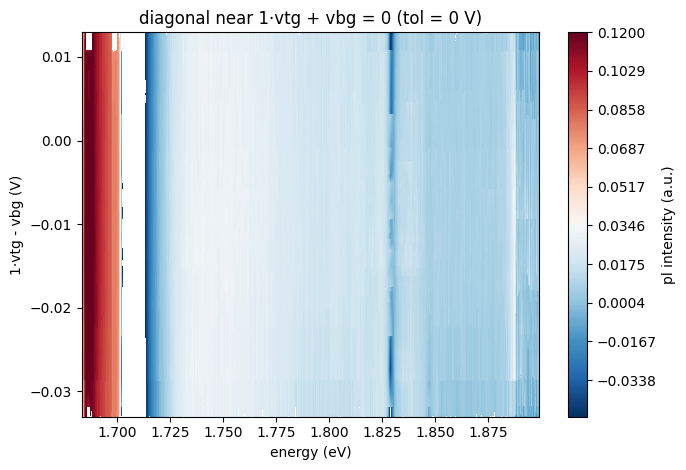

In [ ]:
# ---------- example usage (for c = 0) ----------
from scipy.signal import medfilt2d

tg_bg_ratio = 1  # ratio of Vtg to Vbg, e.g., 1.27 for 1.27·Vtg + Vbg


epsilon = 0 # try 0.01–0.02; 0.02 matches the lattice granularity
c_value = 0

selected_data, vbg_sel, vtg_sel = extract_diagonal_with_tolerance(tg_bg_ratio=tg_bg_ratio,
    Raw_Intensity=RC_spectra,
    vbg_data=vbg_data,
    vtg_data=vtg_data,
    vbg_length=vbg_length,
    vtg_length=vtg_length,
    energy=energy,
    c_value = c_value,
    epsilon = epsilon,        # try 0.01–0.02; 0.02 matches the lattice granularity
    order_along='vtg'
)

# build e-field axis and spectra block
efield_line = tg_bg_ratio * selected_data[:, 1] - selected_data[:, 0]
spectra_block = selected_data[:, :]  # shape: (n_sel, n_energy)

# mesh and plot with contourf
energy_grid, efield_grid = np.meshgrid(energy, efield_line)
plt.figure(figsize=(7, 4.8))
# contours = plt.contourf(energy_grid, efield_grid, spectra_block, levels=200, cmap='RdBu_r')
contours = plt.contourf(energy_grid, efield_grid, spectra_block, 
                        levels=np.linspace(-0.05,0.12,200), 
                        cmap='RdBu_r')
plt.colorbar(contours, label='pl intensity (a.u.)')
plt.xlabel('energy (eV)')
plt.ylabel(f'{tg_bg_ratio}·vtg - vbg (V)')

# plt.ylim(-tg_bg_ratio*20-16,tg_bg_ratio*20+16)
plt.title(f'diagonal near {tg_bg_ratio}·vtg + vbg = {c_value} (tol = {epsilon} V)')
plt.tight_layout()
plt.show()


In [ ]:
# 
Intensity = RC_spectra

# Extract ALL S lines (doping)
extract_all_lines(Intensity, energy, vbg_data, vtg_data, tg_bg_ratio,
                  mode='S',
                  title_prefix='Doping=',
                  y_label=rf'{tg_bg_ratio}·Vtg − Vbg (V)',
                  out_prefix=f'{titlename}_Doping',
                  out_dir='./Doping_lines',
                  wavelength=wavelength,
                  apply_medfilt=False,
                  clim=(-0.05,0.12))

# Extract ALL U lines (E-field)
extract_all_lines(Intensity, energy, vbg_data, vtg_data,tg_bg_ratio,
                  mode='U',
                  title_prefix='Efield=',
                  y_label=rf'{tg_bg_ratio}·Vtg + Vbg (V)',
                  out_prefix=f'{titlename}_Efield',
                  out_dir='./Efield_lines',
                  wavelength=wavelength,
                  apply_medfilt=False,
                  clim=(-0.05,0.12))